# ApacheJIT - Exploratory Data Analysis

Exploratory analysis of `data/raw/apachejit_total.csv` ([ApacheJIT](https://zenodo.org/records/5907002),
Zenodo record 5907002): commit-level features for just-in-time (JIT) defect
prediction across 15 Apache projects, 2003-2019.

The label is derived from the `buggy` column exactly as in
[`src/verify_data.py`](../src/verify_data.py): `label = buggy.astype(int)`.

This notebook checks the assumptions the modeling pipeline will rely on:

1. Class balance (expected ~26.5% positive)
2. Missing values per column
3. Summary statistics for the four Kamei et al. feature groups
4. Feature correlations, flagging any `|r| > 0.8` (Kamei et al. report EXP-REXP
   as highly correlated)
5. Commit date coverage, to confirm the data spans enough time for a
   time-based train/test split


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

# Palette (fixed roles, not cycled) --------------------------------------
BLUE = "#2a78d6"      # categorical slot 1 / sequential hue - "clean" / magnitude
RED = "#e34948"       # categorical slot 8 - "buggy"
DIVERGING_MID = "#f0efec"
INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

CORR_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red", [BLUE, DIVERGING_MID, RED]
)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": SECONDARY_INK,
    "text.color": INK,
    "xtick.color": SECONDARY_INK,
    "ytick.color": SECONDARY_INK,
    "axes.grid": False,
    "font.size": 11,
})


def style_axes(ax, y_grid=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    if y_grid:
        ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


## 1. Load data

In [2]:
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_FILE = ROOT / "data" / "raw" / "apachejit_total.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)
df["label"] = df["buggy"].astype(int)  # same derivation as src/verify_data.py

print(f"Loaded {DATA_FILE}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Loaded C:\Users\uragh\jit-defect-prediction\data\raw\apachejit_total.csv
Shape: 106,674 rows x 19 columns


,commit_id,project,buggy,fix,year,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp,label
0,7b8480744ea6e6fb41efd4329bb470c8f3c763db,apache/groovy,False,False,2003,1070355653,372,23,8,3,3,2.669743,0.250000,3.625000,2.125,243,243.0,0.683585,0
1,192b631e7be302ecde822546ba70a9853ddbda01,apache/groovy,False,False,2003,1063298262,2,2,2,2,1,1.000000,1.000000,0.000000,2.500,19,19.0,14.000000,0
2,0ab6465a7dece117c61c3efd3ec95d20524bdad6,apache/groovy,False,False,2003,1069704572,41,26,3,3,2,1.237612,0.666667,5.333333,45.000,233,233.0,0.000606,0
3,449241d5fa1aeadd5eb9fa1280d4104dc0dfb891,apache/groovy,False,False,2003,1068487625,8,6,2,1,1,0.591673,1.000000,3.000000,35.500,64,64.0,55.000000,0
4,698df9f5b0816e05bbf97a390428f8ef94e0cdbf,apache/groovy,False,False,2003,1063313516,70,4,6,3,1,2.519672,0.333333,0.000000,6.000,27,27.0,22.000000,0


### Feature name mapping

The Kamei et al. (2013) JIT feature names used in the task brief map onto this
CSV's (lowercase) columns as follows. Note **LT (lines of code in the file
before the change)** is *not* present in the ApacheJIT export - only LA and LD
are available for the "size" group.

| Group | Kamei name | Column | Present? |
|---|---|---|---|
| Diffusion | NS | `ns` | yes |
| Diffusion | ND | `nd` | yes |
| Diffusion | NF | `nf` | yes |
| Diffusion | Entropy | `ent` | yes |
| Size | LA | `la` | yes |
| Size | LD | `ld` | yes |
| Size | LT | - | **missing from this dataset** |
| History | NDEV | `ndev` | yes |
| History | AGE | `age` | yes |
| History | NUC | `nuc` | yes |
| Experience | EXP | `aexp` | yes |
| Experience | REXP | `arexp` | yes |
| Experience | SEXP | `asexp` | yes |

Other columns: `commit_id`, `project` (15 Apache projects), `fix` (whether the
commit is itself a bug fix), `year`, `author_date` (Unix timestamp), `buggy`
(label source).


In [3]:
DIFFUSION = ["ns", "nd", "nf", "ent"]
SIZE = ["la", "ld"]
HISTORY = ["ndev", "age", "nuc"]
EXPERIENCE = ["aexp", "arexp", "asexp"]
ALL_NUMERIC_FEATURES = DIFFUSION + SIZE + HISTORY + EXPERIENCE

df.dtypes.astype(str).to_frame("dtype")


,dtype
commit_id,object
project,object
buggy,bool
fix,bool
year,int64
author_date,int64
la,int64
ld,int64
nf,int64
nd,int64


## 2. Class balance

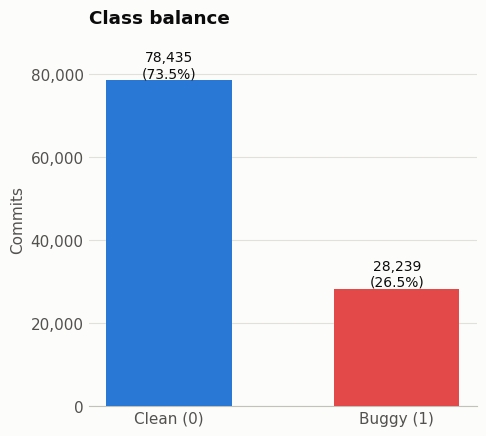

Positive rate: 26.47% (expected ~26.5%)


In [4]:
counts = df["label"].value_counts().sort_index()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(
    ["Clean (0)", "Buggy (1)"],
    counts.values,
    color=[BLUE, RED],
    width=0.55,
    zorder=3,
)
for bar, count, p in zip(bars, counts.values, pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({p:.1f}%)",
        ha="center",
        va="bottom",
        color=INK,
        fontsize=10,
    )

style_axes(ax)
ax.set_ylabel("Commits")
ax.set_title("Class balance", color=INK, fontweight="bold", loc="left")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.margins(y=0.15)
fig.tight_layout()
fig.savefig(FIG_DIR / "class_balance.png", dpi=150, facecolor=SURFACE)
plt.show()

print(f"Positive rate: {pct.loc[1]:.2f}% (expected ~26.5%)")


## 3. Missing values

In [5]:
missing = df.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(3)
missing = missing.sort_values("missing_count", ascending=False)
missing


,missing_count,missing_pct
commit_id,0,0.0
project,0,0.0
buggy,0,0.0
fix,0,0.0
year,0,0.0
author_date,0,0.0
la,0,0.0
ld,0,0.0
nf,0,0.0
nd,0,0.0


In [6]:
total_missing = int(missing["missing_count"].sum())

if total_missing == 0:
    print("No missing values in any column - dataset is fully dense.")
else:
    nonzero = missing[missing["missing_count"] > 0]
    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.35 * len(nonzero))))
    ax.barh(nonzero.index[::-1], nonzero["missing_count"][::-1], color=BLUE, zorder=3)
    style_axes(ax, y_grid=False)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Missing values")
    ax.set_title("Missing values per column", color=INK, fontweight="bold", loc="left")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "missing_values.png", dpi=150, facecolor=SURFACE)
    plt.show()


No missing values in any column - dataset is fully dense.


## 4. Summary statistics by feature group

Kamei et al. group the JIT features into diffusion (how scattered a change
is), size (how large a change is), history (how mature the touched code and
its authors are), and experience (how familiar the author is with the code).


In [7]:
def group_summary(cols, label):
    print(f"--- {label} ---")
    display(df[cols].describe().T)

group_summary(DIFFUSION, "Diffusion: NS, ND, NF, Entropy")


--- Diffusion: NS, ND, NF, Entropy ---


,count,mean,std,min,25%,50%,75%,max
ns,106674.0,1.421237,0.975167,1.0,1.0,1.0,2.000000,45.000000
nd,106674.0,2.943163,3.417911,1.0,1.0,2.0,3.000000,89.000000
nf,106674.0,6.355813,10.141968,1.0,1.0,3.0,7.000000,100.000000
ent,106674.0,1.303768,1.243168,0.0,0.0,1.0,2.049585,6.569856


In [8]:
group_summary(SIZE, "Size: LA, LD (LT unavailable in this dataset)")

--- Size: LA, LD (LT unavailable in this dataset) ---


,count,mean,std,min,25%,50%,75%,max
la,106674.0,189.132347,533.157639,0.0,7.0,37.0,147.0,9967.0
ld,106674.0,76.731490,312.676802,0.0,2.0,9.0,41.0,9950.0


In [9]:
group_summary(HISTORY, "History: NDEV, AGE, NUC")

--- History: NDEV, AGE, NUC ---


,count,mean,std,min,25%,50%,75%,max
ndev,106674.0,5.231532,9.106553,0.0,1.000000,2.333333,5.875,167.500000
age,106674.0,60.326787,136.148017,0.0,1.333333,13.818182,57.000,2713.057143
nuc,106674.0,90.906817,251.273617,0.0,5.000000,15.000000,51.000,3704.500000


In [10]:
group_summary(EXPERIENCE, "Experience: EXP (aexp), REXP (arexp), SEXP (asexp)")

--- Experience: EXP (aexp), REXP (arexp), SEXP (asexp) ---


,count,mean,std,min,25%,50%,75%,max
aexp,106674.0,1225.425230,2704.082920,0.0,49.0,222.000000,829.000000,15795.00
arexp,106674.0,606.947214,1010.400627,0.0,44.5,180.333333,609.858333,4841.25
asexp,106674.0,402.826285,991.485778,0.0,1.0,36.000000,267.000000,7842.00


## 5. Correlation matrix

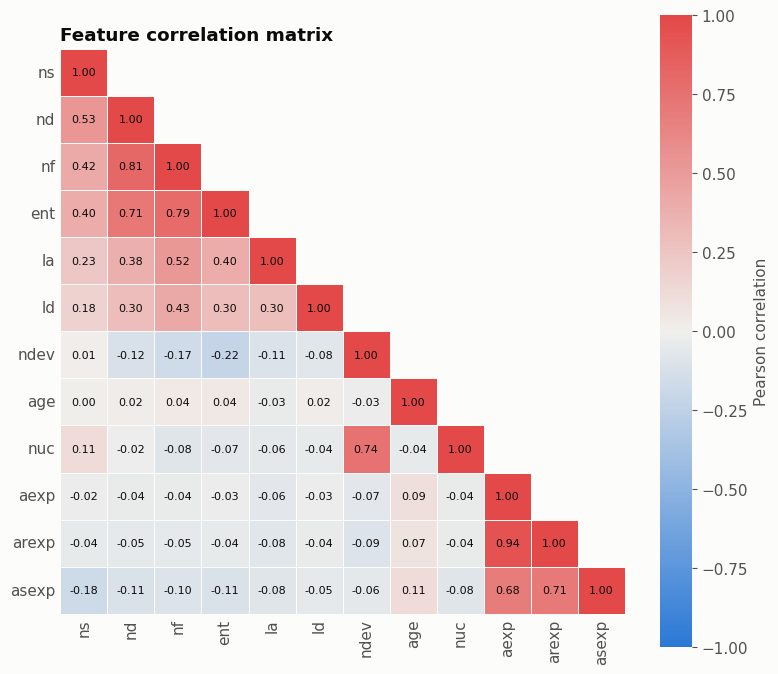

In [11]:
corr = df[ALL_NUMERIC_FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr,
    mask=mask,
    cmap=CORR_CMAP,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor=SURFACE,
    cbar_kws={"label": "Pearson correlation"},
    annot_kws={"fontsize": 8, "color": INK},
    ax=ax,
)
ax.set_title("Feature correlation matrix", color=INK, fontweight="bold", loc="left")
ax.tick_params(length=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_matrix.png", dpi=150, facecolor=SURFACE)
plt.show()


In [12]:
pairs = (
    corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
pairs["abs_correlation"] = pairs["correlation"].abs()
flagged = pairs[pairs["abs_correlation"] > 0.8].sort_values(
    "abs_correlation", ascending=False
)

if flagged.empty:
    print("No feature pairs with |correlation| > 0.8.")
else:
    print("Feature pairs with |correlation| > 0.8:")
    display(flagged.drop(columns="abs_correlation").reset_index(drop=True))

exp_rexp_corr = df["aexp"].corr(df["arexp"])
print(
    f"\nEXP (aexp) vs REXP (arexp) correlation: {exp_rexp_corr:.3f}"
    + (
        " - matches Kamei et al.'s report of high EXP-REXP collinearity."
        if abs(exp_rexp_corr) > 0.8
        else " - not highly correlated in this dataset, unlike Kamei et al.'s report."
    )
)


Feature pairs with |correlation| > 0.8:


,feature_1,feature_2,correlation
0,aexp,arexp,0.940607
1,nd,nf,0.812121



EXP (aexp) vs REXP (arexp) correlation: 0.941 - matches Kamei et al.'s report of high EXP-REXP collinearity.


## 6. Commit date distribution

In [13]:
df["author_datetime"] = pd.to_datetime(df["author_date"], unit="s")

date_min, date_max = df["author_datetime"].min(), df["author_datetime"].max()
span_years = (date_max - date_min).days / 365.25

print(f"Date range: {date_min.date()} -> {date_max.date()} ({span_years:.1f} years)")
print(f"Projects: {df['project'].nunique()}")


Date range: 2003-09-11 -> 2019-12-26 (16.3 years)
Projects: 15


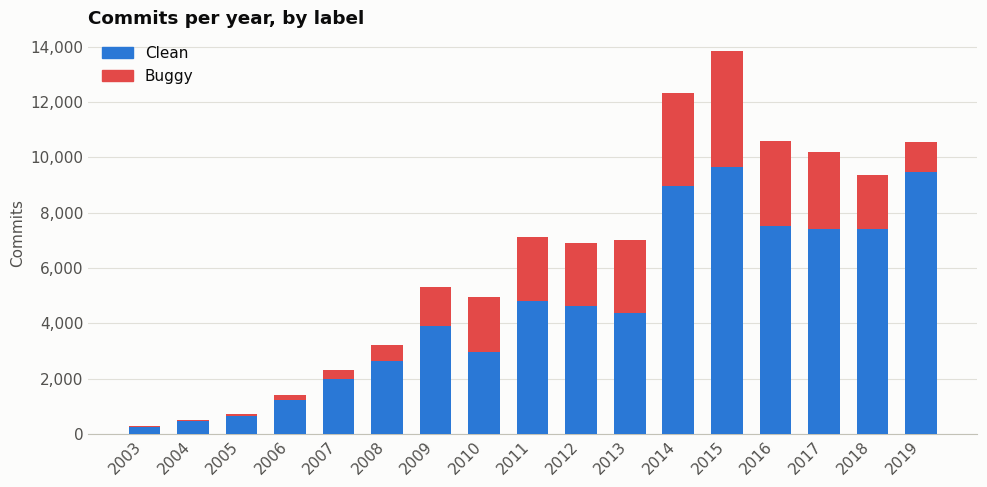

In [14]:
by_year = (
    df.groupby(["year", "label"]).size().unstack(fill_value=0).rename(columns={0: "Clean", 1: "Buggy"})
)

fig, ax = plt.subplots(figsize=(10, 5))
years = by_year.index.astype(str)
ax.bar(years, by_year["Clean"], color=BLUE, width=0.65, label="Clean", zorder=3)
ax.bar(
    years,
    by_year["Buggy"],
    bottom=by_year["Clean"],
    color=RED,
    width=0.65,
    label="Buggy",
    zorder=3,
)

style_axes(ax)
ax.set_ylabel("Commits")
ax.set_title(
    "Commits per year, by label", color=INK, fontweight="bold", loc="left"
)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(
    handles=[Patch(color=BLUE, label="Clean"), Patch(color=RED, label="Buggy")],
    frameon=False,
    loc="upper left",
)
fig.tight_layout()
fig.savefig(FIG_DIR / "commits_per_year.png", dpi=150, facecolor=SURFACE)
plt.show()


## Summary

- **Class balance**: positive (buggy) rate matches the expected ~26.5%,
  confirming a moderate class imbalance that later modeling steps (e.g.
  class weighting or resampling) need to account for.
- **Missing values**: the dataset is fully dense - no imputation needed.
- **Feature groups**: diffusion, size, history, and experience features are
  all present and on very different scales (e.g. `ent` in [0, ~7] vs `la`/`ld`
  spanning thousands), so scaling will matter for distance- or gradient-based
  models. LT is not available in this ApacheJIT export, unlike the original
  Kamei et al. feature set.
- **Correlation**: see the flagged pairs above (including the EXP/REXP check)
  - highly correlated features are candidates for dropping or combining
  before modeling.
- **Time coverage**: commits span multiple years across 15 projects with
  buggy commits present throughout, supporting a chronological (time-based)
  train/test split rather than a random split.
